In [1]:
import jupyter_black

jupyter_black.load()

In [2]:
# Importing Libraries

import numpy as np
import astropy
import photutils
import ccdproc
from ccdproc import CCDData, combiner
from astropy import units as u
import astropy.io.fits as fits
from astropy.io import ascii

from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from photutils.centroids import centroid_com, centroid_1dg, centroid_2dg
from photutils.aperture import CircularAperture
from photutils.aperture import aperture_photometry
from photutils.background import Background2D
from photutils.background import MedianBackground
from photutils.detection import DAOStarFinder
from photutils.segmentation import detect_sources, deblend_sources, SourceCatalog
from scipy.ndimage import shift
import astroalign as aa
import gc

from astropy.coordinates import SkyCoord

/Users/alec/honours-env/.venv/lib/python3.11/site-packages/google_crc32c/__init__.py:29: RuntimeWarning: As the c extension couldn't be imported, `google-crc32c` is using a pure python implementation that is significantly slower. If possible, please configure a c build environment and compile the extension
  warnings.warn(_SLOW_CRC32C_WARNING, RuntimeWarning)


In [3]:
def quickimdisplay(image, vmin=5, vmax=95, title=""):
    if vmin == vmax:
        vmin = np.percentile(image, 5)
        vmax = np.percentile(image, 95)
    vmin = np.percentile(image, vmin)
    vmax = np.percentile(image, vmax)
    plt.imshow(image, origin="lower", vmin=vmin, vmax=vmax, cmap="inferno")
    plt.xlabel("x pixels")
    plt.ylabel("y pixels")
    plt.title(title)
    s = len(image) / len(image[0])
    if s > 1:
        s = 1
    plt.colorbar(shrink=s, label="Counts")
    plt.show()


def showcatalogue(image, title=""):
    plt.imshow(image, origin="lower", vmin=0, vmax=1, cmap="gray")
    plt.xlabel("x pixels")
    plt.ylabel("y pixels")
    plt.title(title)
    plt.show()

In [4]:
def segment(filename):
    scim = CCDData.read(filename)

    w = scim.wcs

    mean, median, std = astropy.stats.sigma_clipped_stats(
        scim.data, sigma=3.0, maxiters=5
    )
    segimage = detect_sources(scim.data, 2.00 * std, 9, connectivity=4, mask=None)

    outfile = "segmented_" + filename
    hdu = fits.PrimaryHDU(segimage)
    wcsheader = w.to_header(relax=True)
    hdu.header.extend(wcsheader)
    hdu.writeto(outfile, overwrite=True)

    return scim, segimage, w


r_image, r_segmented, r_w = segment("r_median.fits")
b_image, b_segmented, b_w = segment("b_median.fits")
g_image, g_segmented, g_w = segment("g_median.fits")

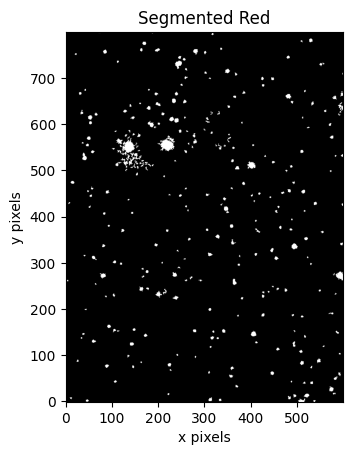

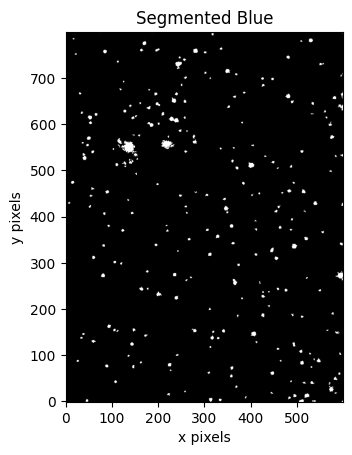

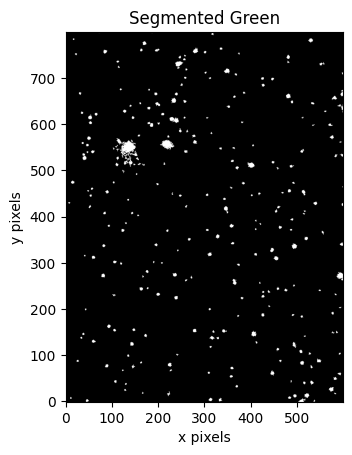

In [5]:
showcatalogue(r_segmented.data, "Segmented Red")
showcatalogue(b_segmented.data, "Segmented Blue")
showcatalogue(g_segmented.data, "Segmented Green")

In [ ]:
r_sources = SourceCatalog(
    r_image.data, r_segmented, error=None, mask=None, background=None, wcs=r_w
)

b_sources = SourceCatalog(
    b_image.data, b_segmented, error=None, mask=None, background=None, wcs=b_w
)

g_sources = SourceCatalog(
    g_image.data, g_segmented, error=None, mask=None, background=None, wcs=g_w
)

In [ ]:
Graham = ascii.read("GrahamGaia.csv", format="csv", fast_reader=False)
# Need to continue from here - calibrate the seestar magnitudes... the csv file is copied from week 4.